# Performance Testing of RRT and RRT-Connect on the Müller-Brown Potential

This notebook tests the path generation of **RRT** and **RRT-Connect** algorithms on the classic Müller-Brown potential energy surface.
We define a custom `MullerBrownEngine` that conforms to PathGennie's `Engine` protocol to run over-damped Langevin dynamics.


In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Optional

# PathGennie imports
from pathgennie.core.engine import Engine
from pathgennie.core.parallel import SerialExecutor
from pathgennie.search.rrt import RRT, rrt_connect


In [ ]:
# Muller-Brown parameters
A = np.array([-200, -100, -170, 15])
a = np.array([-1, -1, -6.5, 0.7])
b = np.array([0, 0, 11, 0.6])
c = np.array([-10, -10, -6.5, 0.7])
x0 = np.array([1, 0, -0.5, -1])
y0 = np.array([0, 0.5, 1.5, 1])

def muller_brown_potential(x, y):
    val = 0.0
    for i in range(4):
        val += A[i] * np.exp(a[i]*(x - x0[i])**2 + b[i]*(x - x0[i])*(y - y0[i]) + c[i]*(y - y0[i])**2)
    return val

def muller_brown_gradient(pos):
    x, y = pos[0], pos[1]
    gx, gy = 0.0, 0.0
    for i in range(4):
        exp_term = np.exp(a[i]*(x - x0[i])**2 + b[i]*(x - x0[i])*(y - y0[i]) + c[i]*(y - y0[i])**2)
        gx += A[i] * exp_term * (2*a[i]*(x - x0[i]) + b[i]*(y - y0[i]))
        gy += A[i] * exp_term * (2*c[i]*(y - y0[i]) + b[i]*(x - x0[i]))
    return np.array([gx, gy], dtype=float)


In [ ]:
class MullerBrownEngine:
    """Over-damped Langevin dynamics on the Muller-Brown surface."""
    def __init__(self, dt: float = 0.0001, kT: float = 10.0, gamma: float = 1.0):
        self.dt = float(dt)
        self.kT = float(kT)
        self.gamma = float(gamma)
        self._cache: Dict[int, np.ndarray] = {}
        self._next_id = 0

    def _store(self, pos: np.ndarray) -> int:
        handle = self._next_id
        self._next_id += 1
        self._cache[handle] = np.asarray(pos, dtype=float).copy()
        return handle

    def create_state(self, position) -> int:
        return self._store(np.asarray(position, dtype=float)[:2])

    def clone_anchor(self, handle: int) -> int:
        return self._store(self._cache[handle])

    def run_segment(
        self, handle: int, n_steps: int, *, randomize_velocities: bool = True, seed: int = 0, device: Optional[int] = None
    ) -> int:
        rng = np.random.default_rng(seed)
        pos = self._cache[handle].copy()
        diffusion = self.kT / self.gamma
        noise_scale = np.sqrt(2.0 * diffusion * self.dt)
        for _ in range(int(n_steps)):
            force = -muller_brown_gradient(pos)
            pos = pos + (force / self.gamma) * self.dt + noise_scale * rng.standard_normal(2)
        return self._store(pos)

    def get_coords(self, handle: int) -> np.ndarray:
        pos = self._cache[handle]
        return np.array([[pos[0], pos[1], 0.0]], dtype=float)

    def release(self, handle: int) -> None:
        self._cache.pop(handle, None)


In [ ]:
# Set up the engine and start/end points
engine = MullerBrownEngine(dt=0.0005, kT=15.0)

# MA (Reactant) and MB (Product)
start_pos = [-0.558, 1.442]
end_pos = [0.623, 0.028]

start_handle = engine.create_state(start_pos)
goal_handle = engine.create_state(end_pos)

# CV projection function (we just take the x, y coordinates)
cv_fn = lambda coords: np.array([coords[0, 0], coords[0, 1]])

print("Running single-tree RRT...")
rrt = RRT(
    engine=engine,
    cv_fn=cv_fn,
    lower=[-1.5, -0.5],
    upper=[1.2, 2.5],
    tau1=5,
    tau2=15,
    n_expand=10,
    sigma=0.5,
    goal_bias=0.1,
    executor=SerialExecutor(),
    seed=42
)
rrt_result = rrt.build(start_handle, target_cv=end_pos, max_iter=2000, goal_tol=0.2)
print(f"RRT Success: {rrt_result.success}, Tree size: {rrt_result.tree_size}")

if rrt_result.success:
    rrt_path = np.array([node.cv for node in rrt_result.path])
else:
    rrt_path = None


Running single-tree RRT...
RRT Success: True, Tree size: 119


In [ ]:
print("Running RRT-Connect...")
rrt_connect_result = rrt_connect(
    engine=engine,
    cv_fn=cv_fn,
    start_handle=start_handle,
    goal_handle=goal_handle,
    lower=[-1.5, -0.5],
    upper=[1.2, 2.5],
    tau1=5,
    tau2=15,
    n_expand=10,
    sigma=0.5,
    max_iter=1000,
    connect_tol=0.2,
    executor=SerialExecutor(),
    seed=42
)
print(f"RRT-Connect Success: {rrt_connect_result.success}, Trees size: {rrt_connect_result.tree_size}")

if rrt_connect_result.success:
    rrt_connect_path = np.array([node.cv for node in rrt_connect_result.path])
else:
    rrt_connect_path = None


Running RRT-Connect...


RRT-Connect Success: True, Trees size: 108


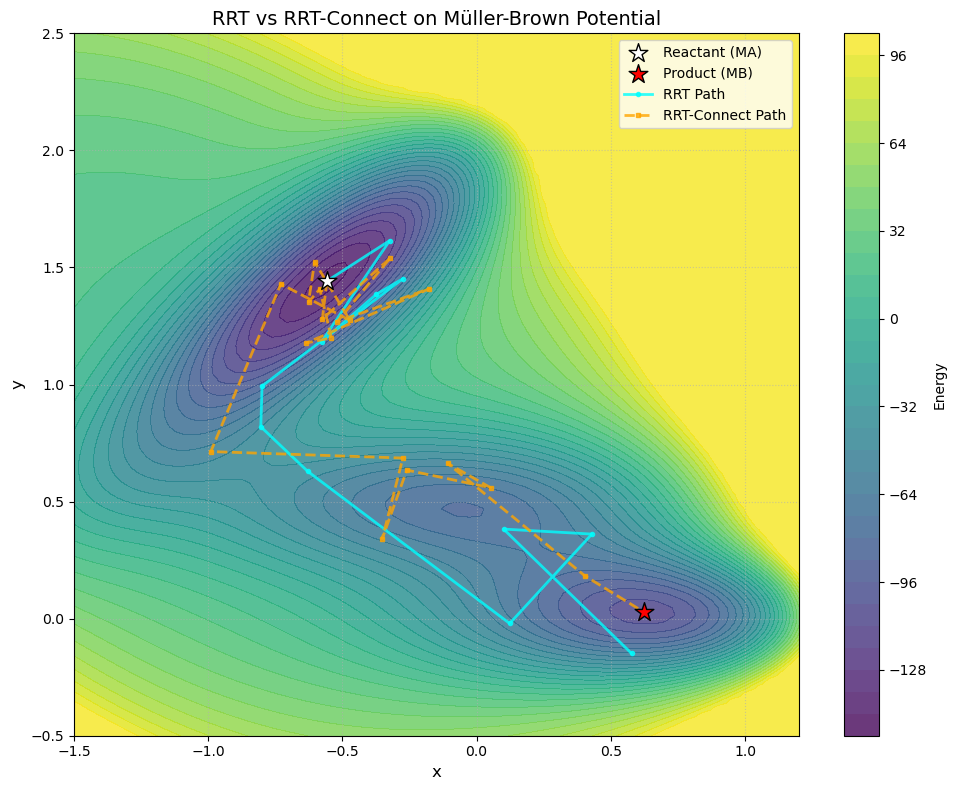

In [ ]:
# Plotting the landscape and paths
x = np.linspace(-1.5, 1.2, 100)
y = np.linspace(-0.5, 2.5, 100)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = muller_brown_potential(X[i, j], Y[i, j])

plt.figure(figsize=(10, 8))
# Clip Z for better contour visualization
Z_clip = np.clip(Z, -200, 100)
contour = plt.contourf(X, Y, Z_clip, levels=40, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Energy')

# Plot start and goal
plt.scatter(*start_pos, color='white', marker='*', s=200, edgecolor='black', label='Reactant (MA)', zorder=5)
plt.scatter(*end_pos, color='red', marker='*', s=200, edgecolor='black', label='Product (MB)', zorder=5)

# Plot RRT path
if rrt_path is not None:
    plt.plot(rrt_path[:, 0], rrt_path[:, 1], color='cyan', marker='o', markersize=3, 
             linewidth=2, label='RRT Path', alpha=0.8)

# Plot RRT-Connect path
if rrt_connect_path is not None:
    plt.plot(rrt_connect_path[:, 0], rrt_connect_path[:, 1], color='orange', marker='s', markersize=3, 
             linewidth=2, linestyle='--', label='RRT-Connect Path', alpha=0.8)

plt.title('RRT vs RRT-Connect on Müller-Brown Potential', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
